## 1. Load manifest

In [10]:
from pathlib import Path

ROOT = Path("..")
MANIFEST = ROOT / "data/processed/manifest.csv"
RESULTS_FIG = ROOT / "results/figures"
RESULTS_LOG = ROOT / "results/logs"

RESULTS_FIG.mkdir(parents=True, exist_ok=True)
RESULTS_LOG.mkdir(parents=True, exist_ok=True)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(MANIFEST)
df.head()

,path,filename,samplerate,channels,frames,duration_sec
0,data/raw/piano/fur_elise/Fur_elise_1.wav,Fur_elise_1.wav,44100,2,1124550,25.5
1,data/raw/piano/fur_elise/Fur_elise_10.wav,Fur_elise_10.wav,44100,2,1124550,25.5
2,data/raw/piano/fur_elise/Fur_elise_11.wav,Fur_elise_11.wav,44100,2,1124550,25.5
3,data/raw/piano/fur_elise/Fur_elise_12.wav,Fur_elise_12.wav,44100,2,1124550,25.5
4,data/raw/piano/fur_elise/Fur_elise_13.wav,Fur_elise_13.wav,44100,2,1124550,25.5


## 2. Basic stats

In [2]:

print("files:", len(df))
print("columns:", list(df.columns))
df.describe(include="all")

files: 62
columns: ['path', 'filename', 'samplerate', 'channels', 'frames', 'duration_sec']


,path,filename,samplerate,channels,frames,duration_sec
count,62,62,62.0,62.0,6.200000e+01,62.000000
unique,62,62,NaN,NaN,NaN,NaN
top,data/raw/piano/fur_elise/Fur_elise_1.wav,Fur_elise_1.wav,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN
mean,NaN,NaN,44100.0,2.0,1.125437e+06,25.520103
std,NaN,NaN,0.0,0.0,6.980562e+03,0.158289
min,NaN,NaN,44100.0,2.0,1.124550e+06,25.500000
25%,NaN,NaN,44100.0,2.0,1.124550e+06,25.500000
50%,NaN,NaN,44100.0,2.0,1.124550e+06,25.500000
75%,NaN,NaN,44100.0,2.0,1.124550e+06,25.500000


In [3]:
dur = df["duration_sec"].astype(float)

stats = {
    "min_sec": float(dur.min()),
    "mean_sec": float(dur.mean()),
    "median_sec": float(dur.median()),
    "max_sec": float(dur.max()),
    "std_sec": float(dur.std()),
}

stats

{'min_sec': 25.5,
 'mean_sec': 25.52010277229171,
 'median_sec': 25.5,
 'max_sec': 26.74637188208617,
 'std_sec': 0.15828938731440995}

In [4]:
sr_counts = df["samplerate"].value_counts()
ch_counts = df["channels"].value_counts()

sr_counts, ch_counts

(samplerate
 44100    62
 Name: count, dtype: int64,
 channels
 2    62
 Name: count, dtype: int64)

## 3. Histograms

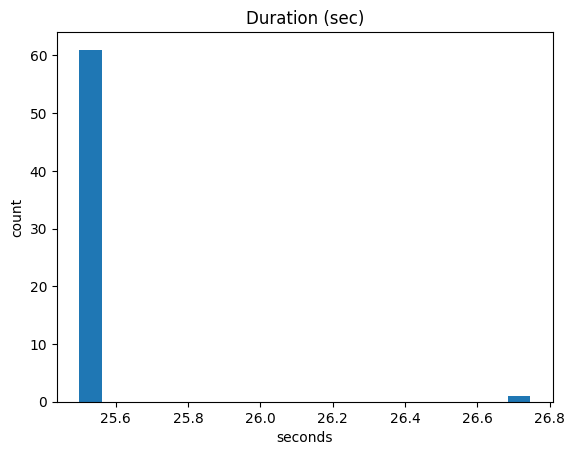

In [5]:
plt.figure()
plt.hist(dur, bins=20)
plt.title("Duration (sec)")
plt.xlabel("seconds")
plt.ylabel("count")
plt.show()

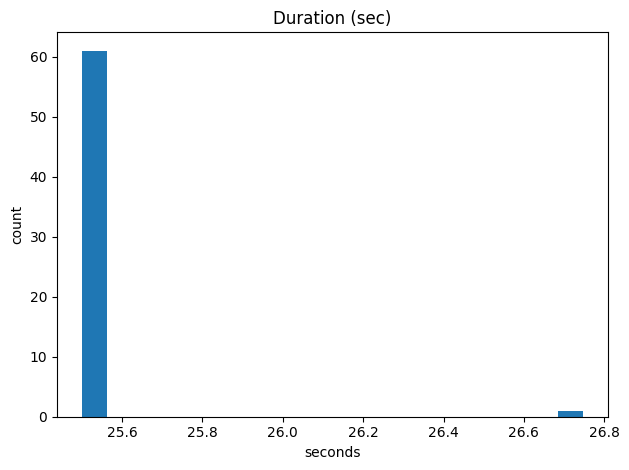

PosixPath('../results/figures/duration_hist.png')

In [12]:
plt.figure()
plt.hist(dur, bins=20)
plt.title("Duration (sec)")
plt.xlabel("seconds")
plt.ylabel("count")
plt.tight_layout()

out_path = RESULTS_FIG / "duration_hist.png"
plt.savefig(out_path, dpi=150)
plt.show()

out_path

In [6]:
q1, q3 = dur.quantile([0.25, 0.75])
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

out = df[(dur < low) | (dur > high)].copy()
out = out.sort_values("duration_sec")

out[["filename", "duration_sec", "samplerate", "channels"]]

,filename,duration_sec,samplerate,channels
51,Fur_elise_56.wav,26.746372,44100,2


In [7]:
shortest = df.sort_values("duration_sec").head(10)
longest = df.sort_values("duration_sec").tail(10)

shortest[["filename", "duration_sec"]], longest[["filename", "duration_sec"]]

(            filename  duration_sec
 0    Fur_elise_1.wav          25.5
 32  Fur_elise_39.wav          25.5
 33   Fur_elise_4.wav          25.5
 34  Fur_elise_40.wav          25.5
 35  Fur_elise_41.wav          25.5
 36  Fur_elise_42.wav          25.5
 37  Fur_elise_43.wav          25.5
 38  Fur_elise_44.wav          25.5
 39  Fur_elise_45.wav          25.5
 40  Fur_elise_46.wav          25.5,
             filename  duration_sec
 21  Fur_elise_29.wav     25.500000
 22   Fur_elise_3.wav     25.500000
 23  Fur_elise_30.wav     25.500000
 24  Fur_elise_31.wav     25.500000
 25  Fur_elise_32.wav     25.500000
 26  Fur_elise_33.wav     25.500000
 27  Fur_elise_34.wav     25.500000
 14  Fur_elise_22.wav     25.500000
 61   Fur_elise_9.wav     25.500000
 51  Fur_elise_56.wav     26.746372)

In [13]:
import random
import soundfile as sf

sample_n = min(10, len(df))
sample_paths = random.sample(df["path"].tolist(), k=sample_n)

rows = []
for rel in sample_paths:
    p = ROOT / rel
    y, sr = sf.read(str(p), dtype="float32")
    if y.ndim > 1:
        y = y.mean(axis=1)

    peak = float(np.max(np.abs(y))) if len(y) else 0.0
    rms = float(np.sqrt(np.mean(y**2))) if len(y) else 0.0
    silence_ratio = float(np.mean(np.abs(y) < 1e-3)) if len(y) else 1.0
    clipped = bool(peak >= 0.999)

    rows.append({
        "filename": Path(rel).name,
        "peak": peak,
        "rms": rms,
        "silence_ratio": silence_ratio,
        "clipped": clipped,
    })

qc = pd.DataFrame(rows).sort_values(["clipped", "silence_ratio"], ascending=[False, False])
qc

,filename,peak,rms,silence_ratio,clipped
5,Fur_elise_45.wav,0.988500,0.117954,0.670028,False
9,Fur_elise_62.wav,0.988500,0.078507,0.659172,False
6,Fur_elise_54.wav,0.750299,0.102067,0.650782,False
4,Fur_elise_52.wav,0.887250,0.081181,0.648079,False
0,Fur_elise_46.wav,0.988500,0.118503,0.585544,False
3,Fur_elise_50.wav,0.988500,0.118471,0.562069,False
8,Fur_elise_39.wav,0.988500,0.143285,0.561112,False
2,Fur_elise_27.wav,0.988500,0.129812,0.551505,False
7,Fur_elise_33.wav,0.988500,0.127288,0.547974,False
1,Fur_elise_3.wav,0.988500,0.106333,0.499700,False


In [14]:
qc[(qc["clipped"] == True) | (qc["silence_ratio"] > 0.85)]

,filename,peak,rms,silence_ratio,clipped


## 4. Play sounds

In [8]:
import random
import librosa
import soundfile as sf
from IPython.display import Audio, display

base = Path("..")

sample_files = random.sample(df["path"].tolist(), k=min(3, len(df)))

for p in sample_files:
    p = base / p
    y, sr = librosa.load(p, sr=None, mono=True)
    print(p.name, "sr:", sr, "sec:", round(len(y)/sr, 2))
    display(Audio(y, rate=sr))

Fur_elise_58.wav sr: 44100 sec: 25.5


Fur_elise_7.wav sr: 44100 sec: 25.5


Fur_elise_9.wav sr: 44100 sec: 25.5


## 5. Save results

In [9]:
from pathlib import Path
import json

Path("../results/logs").mkdir(parents=True, exist_ok=True)

summary = {
    "n_files": int(len(df)),
    "samplerates": df["samplerate"].value_counts().to_dict(),
    "channels": df["channels"].value_counts().to_dict(),
    "duration_sec": {k: round(v, 4) for k, v in stats.items()},
}

Path("../results/logs/dataset_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

summary

{'n_files': 62,
 'samplerates': {44100: 62},
 'channels': {2: 62},
 'duration_sec': {'min_sec': 25.5,
  'mean_sec': 25.5201,
  'median_sec': 25.5,
  'max_sec': 26.7464,
  'std_sec': 0.1583}}

In [15]:
qc_path = ROOT / "data/processed/qc_sample.csv"
if "qc" in globals():
    qc.to_csv(qc_path, index=False)

summary["figures"] = {
    "duration_hist": str(RESULTS_FIG / "duration_hist.png"),
}
summary["qc_sample_csv"] = str(qc_path) if qc_path.exists() else None

(Path(RESULTS_LOG) / "dataset_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

summary

{'n_files': 62,
 'samplerates': {44100: 62},
 'channels': {2: 62},
 'duration_sec': {'min_sec': 25.5,
  'mean_sec': 25.5201,
  'median_sec': 25.5,
  'max_sec': 26.7464,
  'std_sec': 0.1583},
 'figures': {'duration_hist': '../results/figures/duration_hist.png'},
 'qc_sample_csv': '../data/processed/qc_sample.csv'}